In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import pandas as pd
from src.features import compute_daily_returns, get_close_prices

In [3]:
data = pd.read_parquet("/Users/wuyiwen/hk/data/raw/prices.parquet")
data.shape

(119, 50)

In [4]:
close_prices = get_close_prices(data)
close_prices.head()

,1088.HK,2628.HK,1398.HK,0700.HK,0883.HK,3988.HK,0857.HK,0939.HK,1288.HK,0941.HK
Date,,,,,,,,,,
2026-01-02,38.488586,28.098551,6.164671,615.825073,21.389618,4.423877,8.268428,7.603889,5.686519,80.968651
2026-01-05,37.751038,29.053354,6.038267,617.307800,20.685108,4.355516,7.977286,7.477157,5.501194,79.852852
2026-01-06,38.566227,30.300447,6.038267,625.215637,20.841665,4.345750,8.016105,7.535648,5.423163,79.755821
2026-01-07,38.721500,31.001936,5.970202,617.307800,20.215439,4.345750,7.783192,7.428414,5.364640,78.979614
2026-01-08,39.711369,30.339418,5.931308,608.905701,20.235008,4.316453,7.734668,7.418666,5.393902,78.542992


In [5]:
pair = ["0939.HK", "1398.HK"]
pair_prices = close_prices[pair].dropna(how="any")
pair_prices.head()

,0939.HK,1398.HK
Date,,
2026-01-02,7.603889,6.164671
2026-01-05,7.477157,6.038267
2026-01-06,7.535648,6.038267
2026-01-07,7.428414,5.970202
2026-01-08,7.418666,5.931308


<Axes: title={'center': 'Normalized Prices'}, xlabel='Date'>

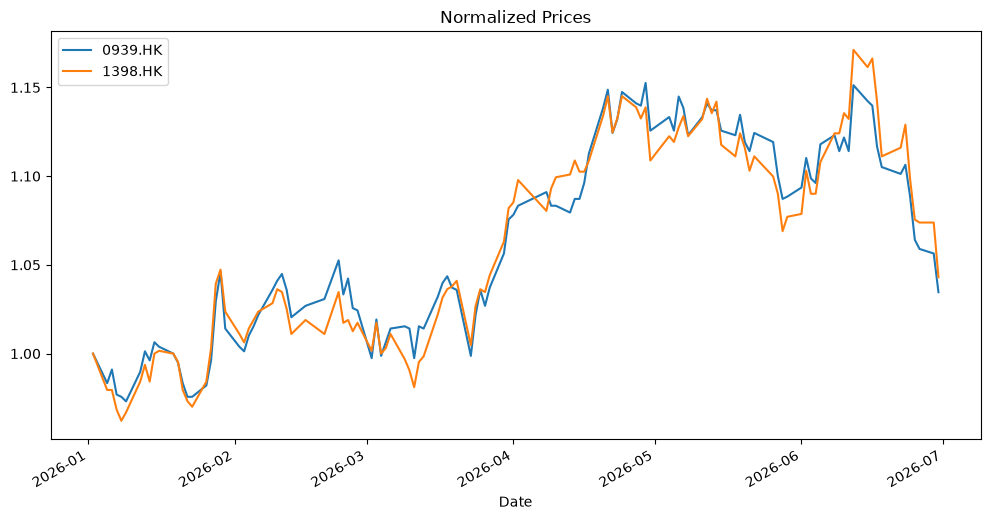

In [6]:
normalized = pair_prices / pair_prices.iloc[0]
normalized.plot(figsize=(12, 6), title="Normalized Prices")

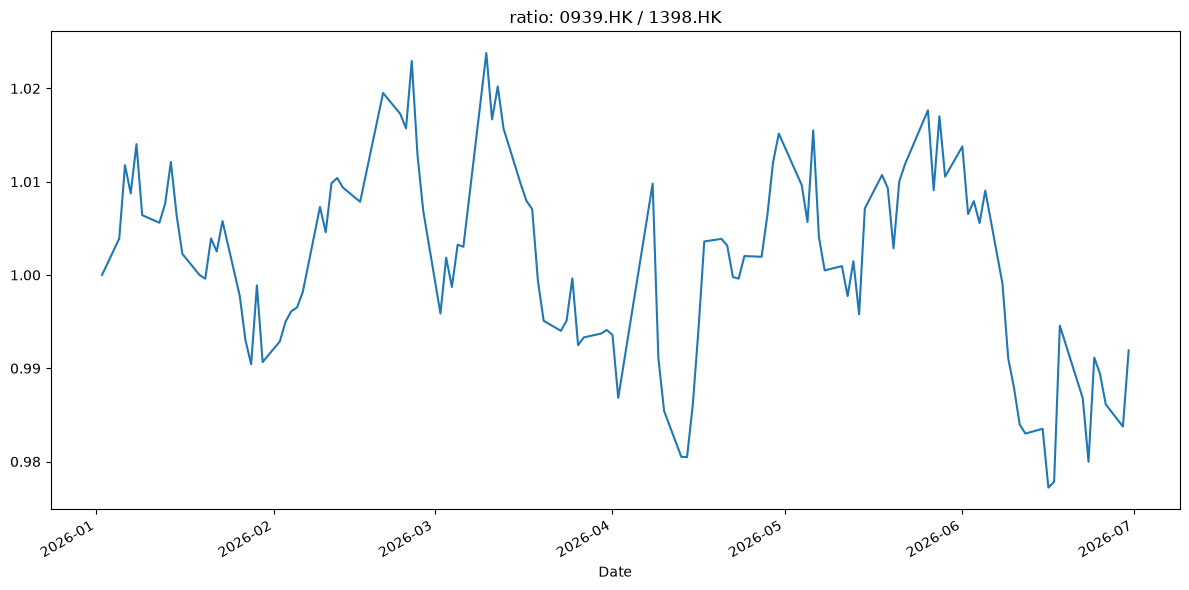

In [7]:
ratio = normalized["0939.HK"] / normalized["1398.HK"]
ratio_chart = ratio.plot(figsize=(12, 6), title="ratio: 0939.HK / 1398.HK")
plt.tight_layout()
plt.show()

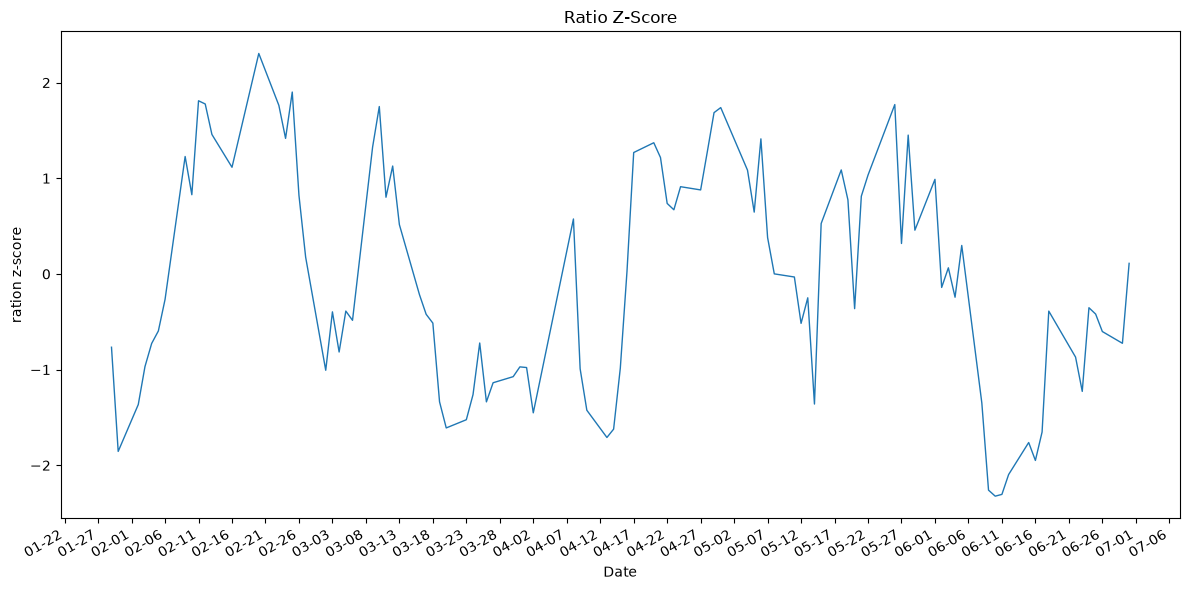

In [12]:
rolling_mean = ratio.rolling(window=20).mean()
rolling_std = ratio.rolling(window=20).std()
z_score = (ratio - rolling_mean) / rolling_std
z_score_chart = z_score.plot(figsize=(12, 6), title="Ratio Z-Score", linewidth=1)
z_score_chart.set_ylabel("ration z-score")
z_score_chart.xaxis.set_major_locator(mdates.DayLocator(interval=5))
z_score_chart.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.tight_layout()
plt.show()

In [38]:
z_score.tail()

Date
2026-06-24   -0.353259
2026-06-25   -0.419501
2026-06-26   -0.601993
2026-06-29   -0.725028
2026-06-30    0.110653
dtype: float64